In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [3]:
file_path = 'Dataset_Forecasting_ARIMA_Lengkap.xlsx'
xls = pd.ExcelFile(file_path)
pivot_harian_df = pd.read_excel(xls, sheet_name='Pivot_Harian_ARIMA')
# Convert Date column to datetime
pivot_harian_df['Date'] = pd.to_datetime(pivot_harian_df['Date'])
pivot_harian_df.set_index('Date', inplace=True)
total_sales = pivot_harian_df['Total_Sales']

In [4]:
# Perform ADF test
adf_result = adfuller(total_sales.dropna())
adf_statistic, p_value = adf_result[0], adf_result[1]
adf_statistic, p_value

(np.float64(-4.513838308664948), np.float64(0.00018562309463748014))

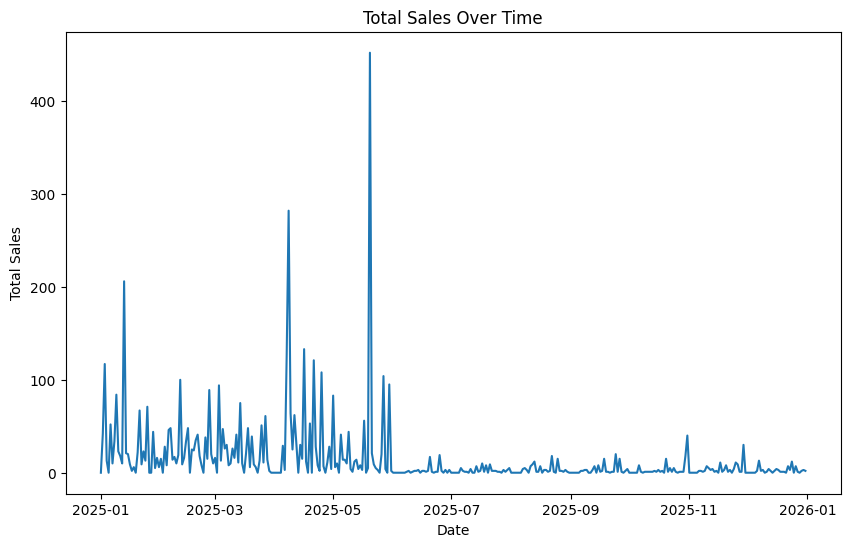

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(total_sales)
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

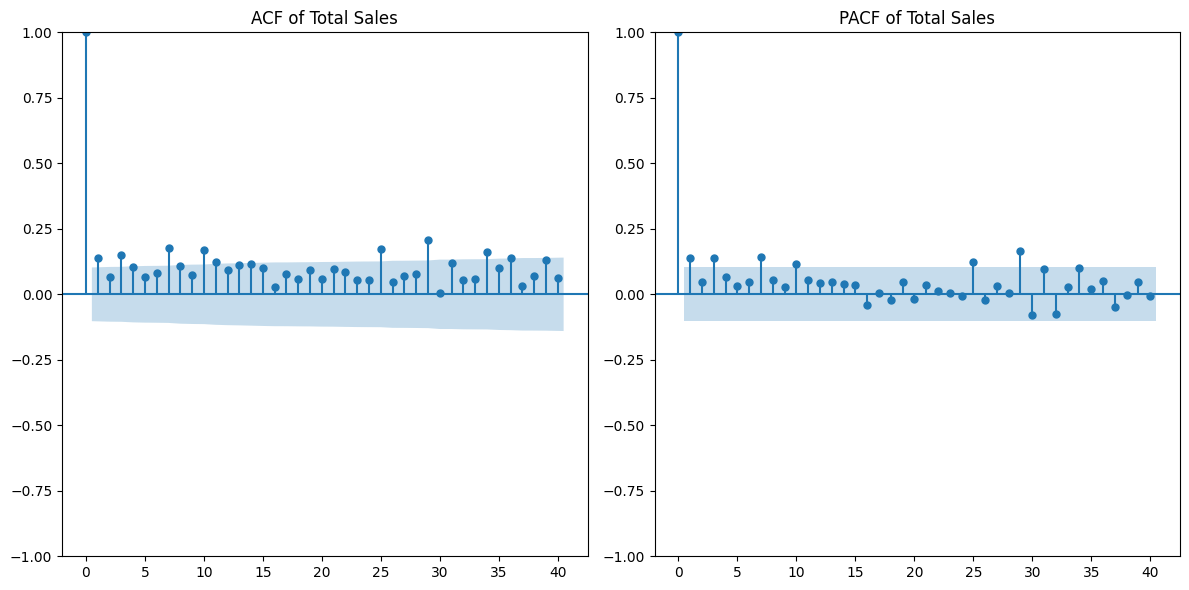

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(total_sales.dropna(), lags=40, ax=plt.gca())
plt.title('ACF of Total Sales')
plt.subplot(122)
plot_pacf(total_sales.dropna(), lags=40, ax=plt.gca())
plt.title('PACF of Total Sales')
plt.tight_layout()
plt.show()

d:\fauzan\coba coba arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\fauzan\coba coba arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\fauzan\coba coba arima\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


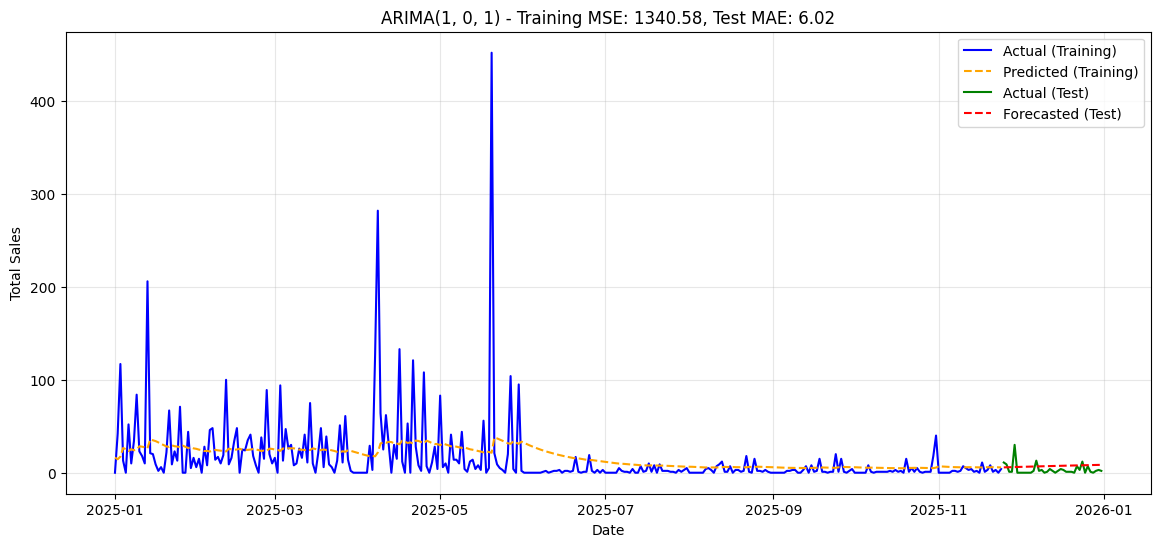

Training MSE: 1340.58
Test MAE: 6.02


In [8]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Split data into training (90%) and test (10%)
train_size = int(len(total_sales) * 0.9)
train_data = total_sales[:train_size]
test_data = total_sales[train_size:]

# Fit ARIMA model on training data
model = ARIMA(train_data, order=(1, 0, 1))
model_fit = model.fit()

# Predicted values on training data
train_predictions = model_fit.predict(start=0, end=len(train_data)-1)

# Forecast for test period
forecast = model_fit.forecast(steps=len(test_data))

# Calculate metrics
mse_train = mean_squared_error(train_data.dropna(), train_predictions)
mae_test = mean_absolute_error(test_data, forecast)

# Plot Actual, Predicted, and Forecasted
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data, label='Actual (Training)', color='blue')
plt.plot(train_data.index, train_predictions, label='Predicted (Training)', linestyle='--', color='orange')
plt.plot(test_data.index, test_data, label='Actual (Test)', color='green')
plt.plot(test_data.index, forecast, label='Forecasted (Test)', linestyle='--', color='red')
plt.title(f'ARIMA(1, 0, 1) - Training MSE: {mse_train:.2f}, Test MAE: {mae_test:.2f}')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'Training MSE: {mse_train:.2f}')
print(f'Test MAE: {mae_test:.2f}')